In [ ]:
# supervised
# unsupervised
# reinforcement - asosan robotlarda ishlatiladi fadebacklarni olabiladi.


In [ ]:
# Project: data, model; data -> model -> output -> loss -> optimization;
# inference (train qilingan modelni deploy qilish) 
# Supervised learning: data == label; 
# outlier: (1,2), (2,3), (4,3)... (10000, 10000)

In [85]:
import os, glob
import urllib.request as r
import shutil


def data_yuklab_olish(saqlash_uchun_papka, data_nomi = "salaries"):

    data_nomlari = ["salaries", "exams", "college", "cars", "mall", "uzbekistan_football"]
    assert data_nomi in data_nomlari, f"Mavjud bo'lgan dataset {data_nomlari} dan birini kiriting!"

    if data_nomi == "college": url = "https://drive.google.com/file/d/1vwfMpQ4ikAI91zn1bWxP_Iqz7DTFUA9F/view?usp=sharing"
    elif data_nomi == "salaries": url = "https://drive.google.com/file/d/1p-XtX29fgXT9CzBfpHm3t8r028gQPRhe/view?usp=sharing"
    elif data_nomi == "exams": url = "https://drive.google.com/file/d/1TYN_sRmauaDgNYgQ-0VSHVAJvLoxKx2R/view?usp=sharing"
    elif data_nomi == "cars": url = "https://drive.google.com/file/d/1Fi5IPdfEktnKyf3dyHmnh84a2jiXl33A/view?usp=sharing"
    elif data_nomi == "mall": url = "https://drive.google.com/file/d/1eGWJVRNmGjfaH0o3dczBbNe_-RrW0_Jm/view?usp=sharing"
    elif data_nomi == "uzbekistan_football": url = "https://drive.google.com/file/d/1eGWJVRNmGjfaH0o3dczBbNe_-RrW0_Jm/view?usp=sharing"
    elif data_nomi == "humanitarian": url = "https://drive.google.com/file/d/1dRv0-5iflumJFcjSHk-Vnjedtsn0WEEQ/view?usp=drive_link"
    elif data_nomi == "customer": url = "https://drive.google.com/file/d/1kW9UY7LI7kbnM5z2jgCMBUPUUMbsPe6p/view?usp=drive_link"

    full_path = f"{saqlash_uchun_papka}/{data_nomi}.zip"
    os.makedirs(saqlash_uchun_papka, exist_ok = True)

    # Download from the checkpoint path
    if os.path.isfile(f"{saqlash_uchun_papka}/{data_nomi}.csv"): print("Data yuklab olingan"); pass

    # If the checkpoint does not exist
    else:
        print("Datani yuklash boshlanmoqda...")

        # Get file id
        file_id = url.split("/")[-2]

        # Initialize prefix to download
        prefix = "https://drive.google.com/uc?/export=download&id="

        # Download the checkpoint
        r.urlretrieve(f"{prefix + file_id}", f"{full_path}")
        shutil.unpack_archive(f"{full_path}", f"{saqlash_uchun_papka}")
        os.remove(full_path)

        files = sorted(glob.glob(f"{saqlash_uchun_papka}/*"), key = os.path.getctime)
        fname = os.path.basename(files[-1])
        os.rename(f"{saqlash_uchun_papka}/{fname}", f"{saqlash_uchun_papka}/{data_nomi}.csv")
        print(f"Data {saqlash_uchun_papka} papkasiga {data_nomi} nomi bilan yuklab olindi.")


In [87]:
import pandas as pd
df = pd.read_csv(filepath_or_buffer="/Users/apple/Course/4-dars/datasetlar/exams.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [50]:
len(df)

1000

In [49]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [ ]:
# feature -> modelimiz o'rganishi kerak bulgan. malumotlar.
# modelling bias (bir tomonga bosish)
# generalizable 

In [51]:
ustunlar = ["narx", "xizmat", "eshiklar", "o'rindiqlar", "bagaj", "xavfsizlik", "javob"]
# df.columns = ustunlar
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [ ]:
# a) data imputation:
# 1) medium -> [1,1,2,3,3,5]
# 2) mean -> [1,1,2,3,3,5]

# class imbalance: oversampling; undersampling; 
# 100 ta bashorat; 10 ta bashorat; 

In [2]:
# np.arange(3)

In [53]:
from matplotlib import pyplot as plt # chizmalar
import numpy as np

def data_analysis(data, ustun_nomi, rang, bar_eni, text_eni):

  # har bir ustundagi (featuredagi) representation
  counts = data[ustun_nomi].value_counts().values   
  cls_names = data[ustun_nomi].value_counts().index

  fig, ax = plt.subplots(figsize = (20, 10))
  indices = np.arange(len(counts))

  ax.bar(indices, counts, bar_eni, color=rang)
  ax.set_xlabel("Klass Nomlari", color = "red", fontsize = 14)
  ax.set_ylabel("Data Miqdorlari", color = "red", fontsize = 14)
  ax.set_title(f"{ustun_nomi} data tahlili")
  # Add set_xticks
  ax.set_xticks(indices) # 0,1,2
  ax.set_xticklabels(cls_names, rotation = 90)
  # ax.set_xticklabels(cls_names)

  # Tekst yozish
  for i, v in enumerate(counts):
    ax.text(i - text_eni, v + text_eni, str(v), color = "blue", fontsize = 10)

  plt.tight_layout()
  plt.show()


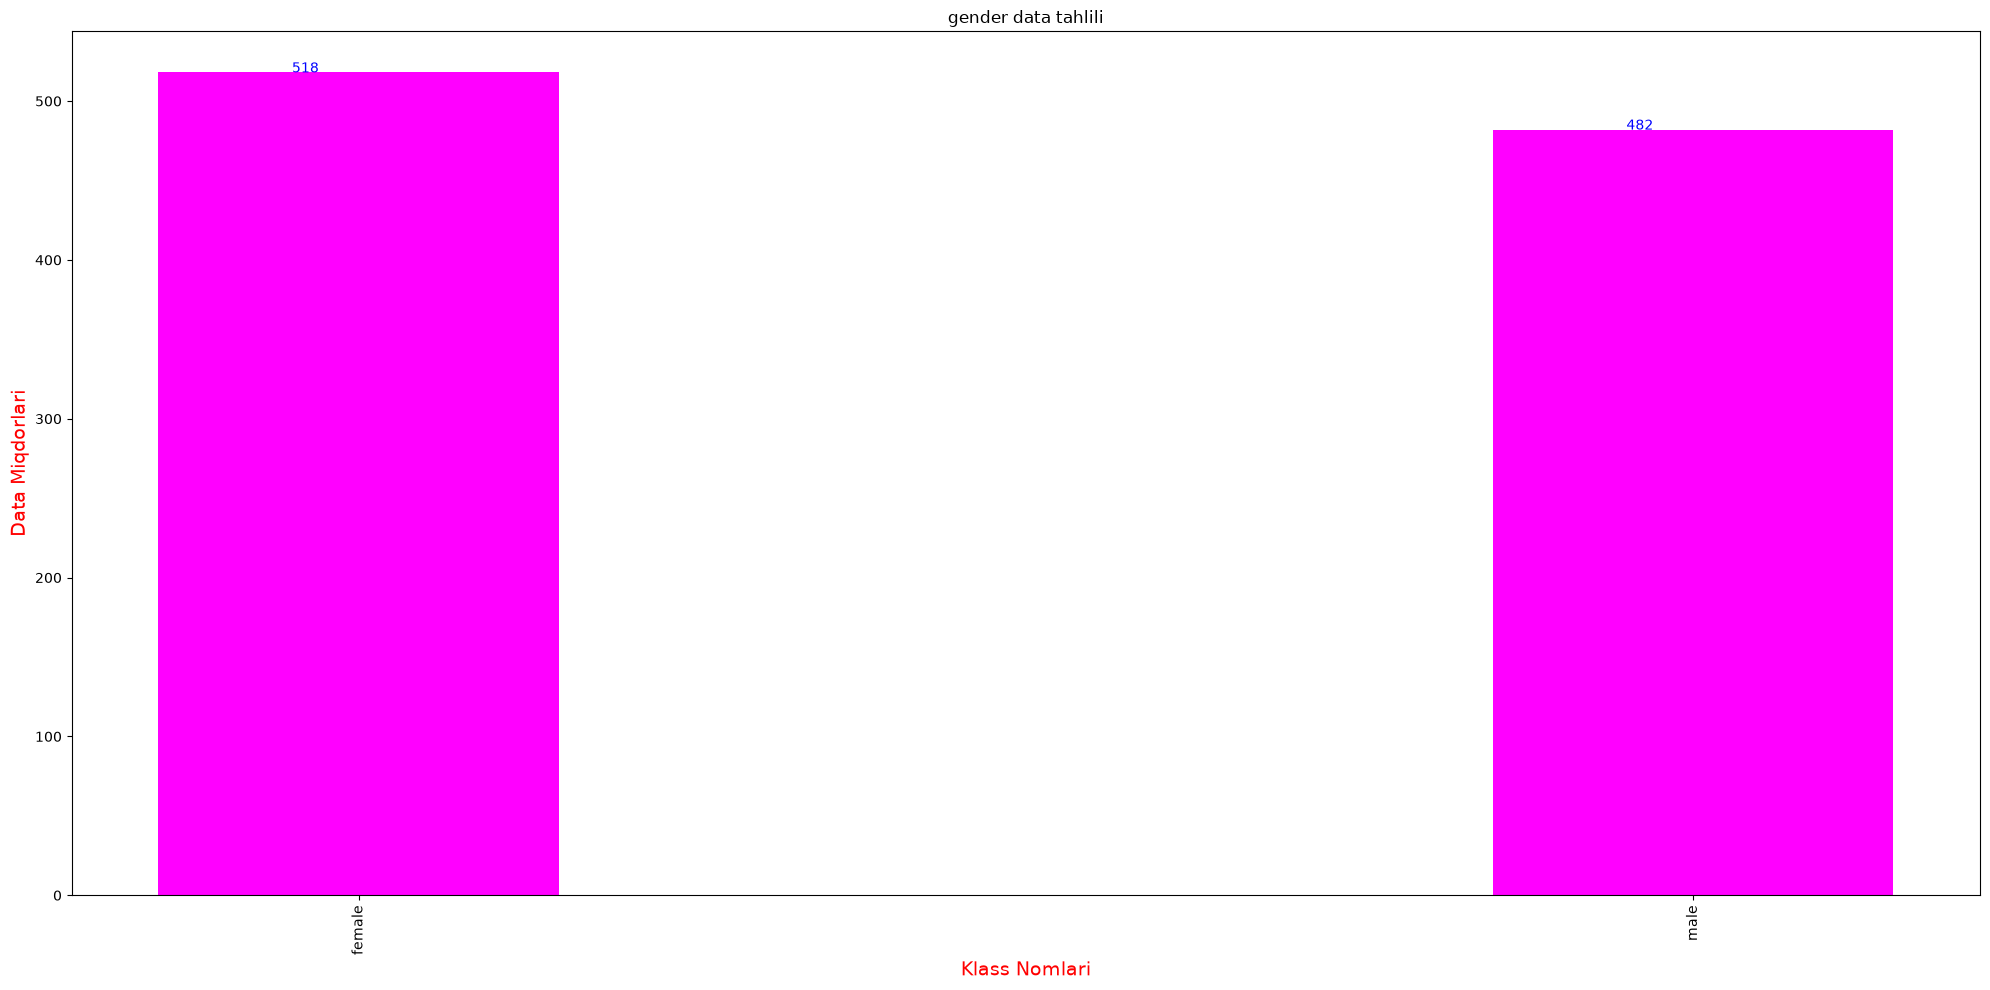

In [54]:
data_analysis(data = df, ustun_nomi="gender", rang = "magenta", bar_eni = 0.3, text_eni = 0.05)

In [55]:
# Classification; regression
# 2 turi: binary (2 ta bo'ladi); multiclass (2dan ortiq)
df["gender"].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [56]:
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [64]:
# 0~
# axis, dimension (dim)

In [58]:
X = df.drop(["gender"], axis=1)
X.head()
# buyerda axis=1 → ustunlar (columns) bo'yicha ishlaydi.
#Ya'ni "club" ustunini o'chiradi.

,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,group B,bachelor's degree,standard,none,72,72,74
1,group C,some college,standard,completed,69,90,88
2,group B,master's degree,standard,none,90,95,93
3,group A,associate's degree,free/reduced,none,47,57,44
4,group C,some college,standard,none,76,78,75


In [59]:
y = df["gender"]
y.head()

0    female
1    female
2    female
3      male
4      male
Name: gender, dtype: str

In [ ]:
# train, validation, test
# trainlar epochlardan tashkil topadi: epoch -> model butun datani bir marta to'liq ko'rib chiqishi
# train jarayonida -> train data -> backprop, optimization - O
# validation jarayonida -> validation data -> backprop, optimization - X
# test jarayonida -> test data -> backprop, optimization - X

# 1 ta epochda train va validation jarayonlari bo'ladi, test bo'lmaydi faqat 1 marta ko'riladi.

In [ ]:
# train jarayonida -> train data -> 70~90%
# validation jarayonida -> validation data -> 5~15%
# test jarayonida -> test data -> backprop, optimization - 5~15%; paper, project (report) -> test data loss, acc (f1, iou, ap)

In [1]:
from sklearn.model_selection import train_test_split
#seed

X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026) #split
X_test, X_valid, y_test, y_valid = train_test_split(X_validation, y_validation, test_size=0.5, random_state=2025) # split
len(X_train)

NameError: name 'X' is not defined

In [61]:
len(X_validation)

200

In [62]:
print(len(df))
print(y.nunique())
print(y.value_counts())

1000
2
gender
female    518
male      482
Name: count, dtype: int64


In [63]:
X_test.head()

,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
619,group C,associate's degree,free/reduced,completed,65,73,68
526,group C,some high school,free/reduced,completed,56,61,60
292,group C,some high school,standard,completed,63,60,57
654,group B,some high school,standard,none,73,79,79
976,group B,some college,free/reduced,completed,60,62,60


In [65]:
y_test

619      male
526      male
292      male
654    female
976      male
        ...  
20       male
521    female
945    female
313    female
592      male
Name: gender, Length: 100, dtype: str

In [ ]:
# son -> standard scaler -> normalization (0 ~ 1000) normal distribution -> mean 0, std 1; 0~1
# (0 ~ 1000) / max_value (0~1)

In [ ]:
# Onehotencoding
# 3 ta data bor: datamizning lengthiga teng bo'lgan array yaratib, ular ichiga 0 yoki 1 sonini qo'yib chiqadi:
# 1 qizil -> [1 0 0]
# 2 ko'k  -> [0 1 0]
# 3 oq    -> [0 0 1]

In [66]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder

In [67]:
encoder = OrdinalEncoder()

In [68]:
X_train_before = X_train
X_train_after = encoder.fit_transform(X_train)
X_train_before

,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
170,group A,high school,standard,completed,72,73,74
865,group D,some college,standard,completed,82,82,88
800,group C,some high school,standard,completed,67,73,68
330,group C,high school,standard,none,71,60,61
77,group A,bachelor's degree,standard,completed,80,78,81
...,...,...,...,...,...,...,...
552,group B,associate's degree,standard,none,40,48,50
327,group A,some college,free/reduced,none,28,23,19
89,group D,some high school,standard,none,73,86,82
390,group E,some high school,free/reduced,completed,73,67,59


In [69]:
X_train_after

array([[ 0.,  2.,  1., ..., 49., 44., 49.],
       [ 3.,  4.,  1., ..., 59., 53., 63.],
       [ 2.,  5.,  1., ..., 44., 44., 43.],
       ...,
       [ 3.,  5.,  1., ..., 50., 57., 57.],
       [ 4.,  5.,  0., ..., 50., 38., 34.],
       [ 4.,  4.,  1., ..., 39., 44., 45.]], shape=(800, 7))

In [70]:
X_train = encoder.fit_transform(X_train)
X_valid = encoder.fit_transform(X_valid)
X_test = encoder.fit_transform(X_test)

In [71]:
# LinearRegression -> decision boundary is too simple
# time and accuracy tradeoff

from sklearn.ensemble import RandomForestClassifier

# ensemble - 2 va undan ortiq classifier ni train qilib, inference (train qilingan modelni deployment (test datani (real-life) datani bashorat) qilish) jarayonida train qilingan classifier lardan foydalanib prrediction qiladi,
# multiclass with 4 classes
# Input test data modelga input qilingach, 1-model: 2, 2-model: 3, 3-model: 2; majority vote
# Inference train qilingan model bilan test datani predication qilish (test jar
# decision tree algorithm: 
# daraxt barglari

In [72]:
rfc = RandomForestClassifier(n_estimators = 10) #
# decision ko'p yoki kamligi?
# vaqt va aniqlik tradeoff 
# ko'p: vaqt ko'p; aniqlilik (accuracy) baland
# kam: vaqt kam ketadi; aniqlilik pasts

In [73]:
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [76]:
# Inference
acc_score = rfc.score(X_test, y_test) # acc score 0~1 * 100
print(f"Aniqlilik -> {(acc_score * 100):.2f}%")

Aniqlilik -> 82.00%


In [77]:
from sklearn.model_selection import cross_val_score
# 30 ta data:
# 1-fold: 10 10 (10) -> score
# 2-fold: 10 (10) 10 -> score
# 3-fold: (10) 10 10 -> score

cross_val_score(rfc, X_train, y_train, cv=5)

array([0.8    , 0.81875, 0.8    , 0.80625, 0.8375 ])

In [78]:
import csv

columns=['narx', 'xizmat', 'eshiklar', "o'rindiqlar", 'bagaj', 'xavfsizlik']

data = [

    {f"{columns[0]}": 'vhigh',
     f"{columns[1]}": 'vhigh',
     f"{columns[2]}": '4',
     f"{columns[3]}": '4',
     f"{columns[4]}": "med",
     f"{columns[5]}": 'high',
     }
]

with open("data.csv", "w") as csvfile:

    writer = csv.DictWriter(csvfile, fieldnames = columns)
    writer.writeheader()
    writer.writerows(data)

In [81]:
# foydalanuvchi
test_data = pd.read_csv("data.csv")
test_data

,narx,xizmat,eshiklar,o'rindiqlar,bagaj,xavfsizlik
0,vhigh,vhigh,4,4,med,high
